In [1]:
import pandas as pd

C:\Users\kumar_santhosh\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\kumar_santhosh\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv('Recommendation System.csv')
df.head()

,Income,Recency,Customer_Days,Total_Spending,Total_Purchases,Cluster,Segment,Recommendation,Strategy,Channels,Offers,Goal
0,58138.0,58,4951,1617,25,3.0,Budget Buyers,"{'Strategy': 'Price-Based Promotions', 'Channe...",Price-Based Promotions,"SMS, Ads","Coupons, Seasonal Discounts",Increase purchase frequency
1,46344.0,38,4401,27,6,1.0,New Customers,"{'Strategy': 'Welcome Campaign', 'Channels': [...",Welcome Campaign,"Email, SMS",First Purchase Discount,Convert into repeat customers
2,71613.0,26,4600,776,21,2.0,At Risk Customers,"{'Strategy': 'Re-engagement Campaign', 'Channe...",Re-engagement Campaign,"Email, Push Notifications",Win-back Discounts,Prevent churn
3,26646.0,26,4427,53,8,1.0,New Customers,"{'Strategy': 'Welcome Campaign', 'Channels': [...",Welcome Campaign,"Email, SMS",First Purchase Discount,Convert into repeat customers
4,58293.0,94,4449,422,19,3.0,Budget Buyers,"{'Strategy': 'Price-Based Promotions', 'Channe...",Price-Based Promotions,"SMS, Ads","Coupons, Seasonal Discounts",Increase purchase frequency


## Segment Distribution ##

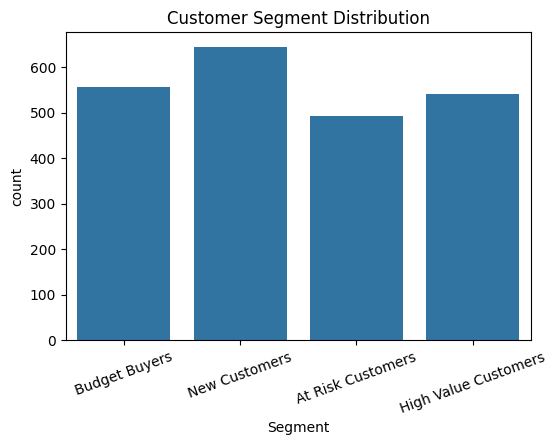

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Segment', data=df)
plt.title('Customer Segment Distribution')
plt.xticks(rotation=20)
plt.show()

## Spending by Segment

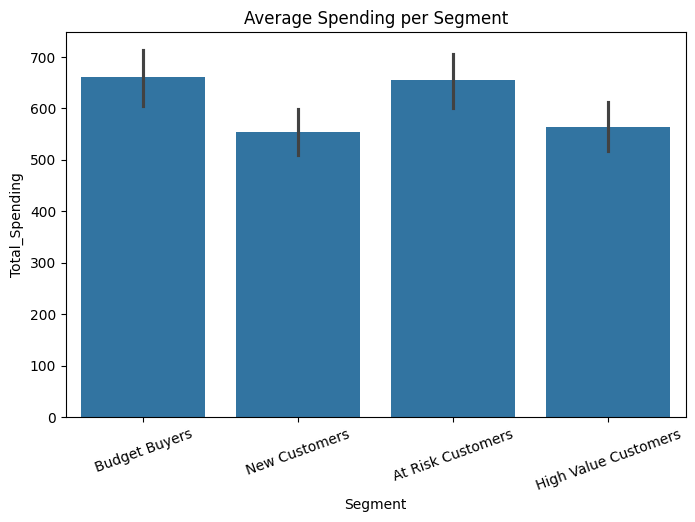

In [4]:
plt.figure(figsize=(8,5))
sns.barplot(x='Segment', y='Total_Spending', data=df)
plt.title('Average Spending per Segment')
plt.xticks(rotation=20)
plt.show()

## Purchase Behavior

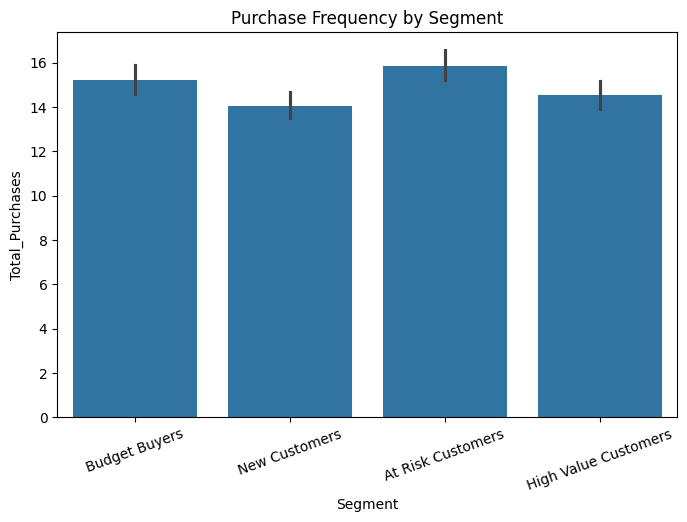

In [5]:
plt.figure(figsize=(8,5))
sns.barplot(x='Segment', y='Total_Purchases', data=df)
plt.title('Purchase Frequency by Segment')
plt.xticks(rotation=20)
plt.show()

## Recency Analysis

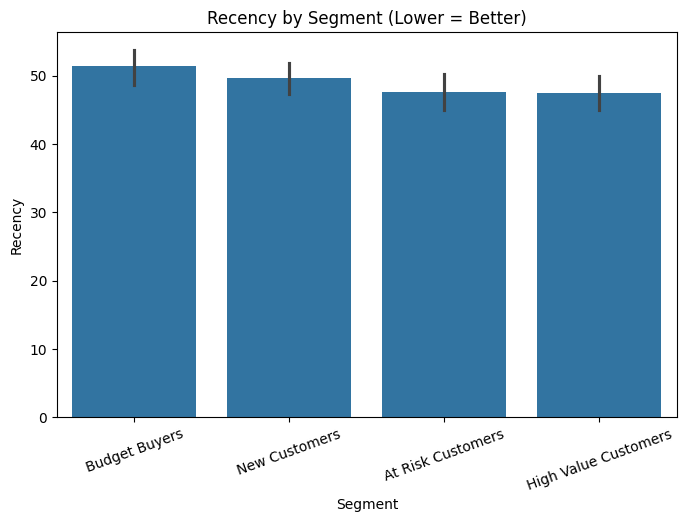

In [7]:
plt.figure(figsize=(8,5))
sns.barplot(x='Segment', y='Recency', data=df)
plt.title('Recency by Segment (Lower = Better)')
plt.xticks(rotation=20)
plt.show()

## Heatmap

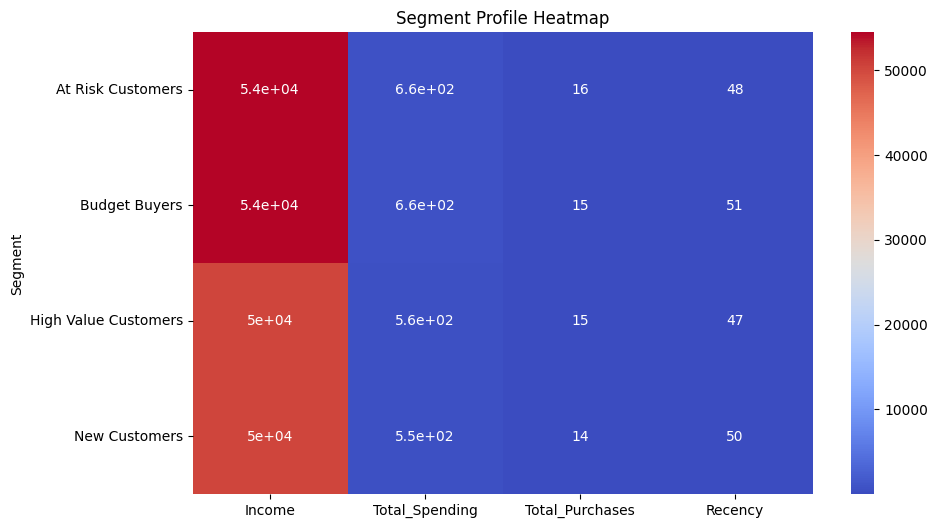

In [8]:
segment_profile = df.groupby('Segment')[[
    'Income', 'Total_Spending', 'Total_Purchases', 'Recency'
]].mean()

plt.figure(figsize=(10,6))
sns.heatmap(segment_profile, annot=True, cmap='coolwarm')
plt.title('Segment Profile Heatmap')
plt.show()

## Recommendation Distribution

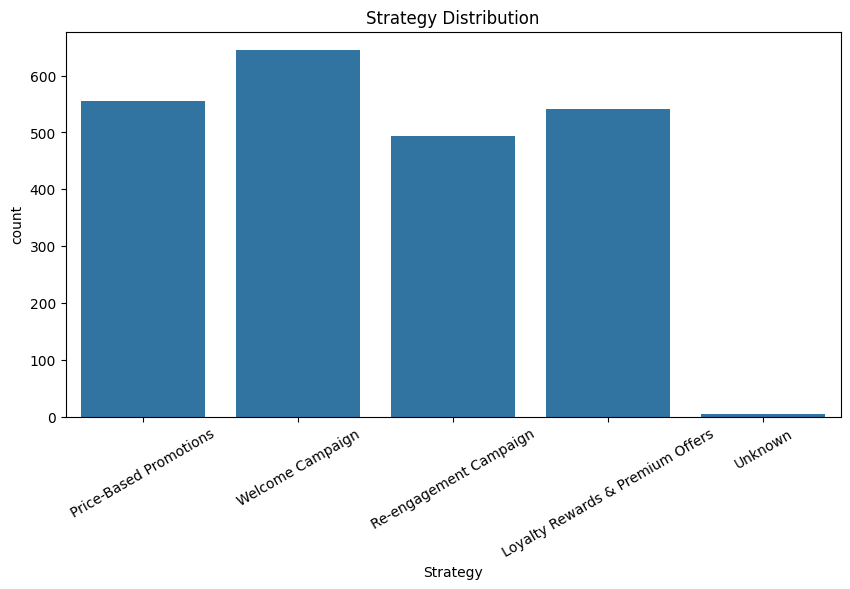

In [9]:
plt.figure(figsize=(10,5))
sns.countplot(x='Strategy', data=df)
plt.title('Strategy Distribution')
plt.xticks(rotation=30)
plt.show()

## Segment vs Channel

In [11]:
df.columns

Index(['Income', 'Recency', 'Customer_Days', 'Total_Spending',
       'Total_Purchases', 'Cluster', 'Segment', 'Recommendation', 'Strategy',
       'Channels', 'Offers', 'Goal'],
      dtype='str')

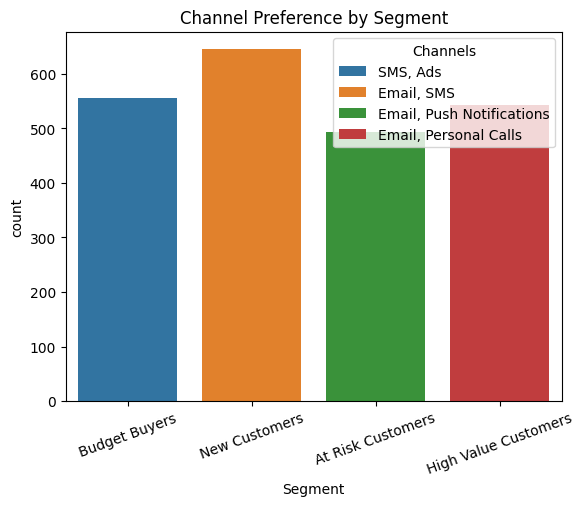

In [18]:
sns.countplot(x='Segment', hue='Channels', data=df_clean)
plt.title('Channel Preference by Segment')
plt.xticks(rotation=20)
plt.show()

In [14]:
unknown_rows = df[df['Channels'] == 'Unknown']
print("Unknown count:", len(unknown_rows))

Unknown count: 4


In [16]:
df_clean = df[df['Channels'] != 'Unknown']

In [17]:
print(df_clean['Channels'].value_counts())

Channels
Email, SMS                   645
SMS, Ads                     556
Email, Personal Calls        542
Email, Push Notifications    493
Name: count, dtype: int64


In [19]:
df_clean.to_csv('final_dashboard_dataset.csv', index=False)

In [21]:
df_1 = pd.read_csv('cluster_profile.csv')

In [22]:
df_1.columns

Index(['Clusters', 'Income', 'Recency', 'Customer_Days', 'Total_Spending',
       'Total_Purchases', 'Count'],
      dtype='str')